Problema a resolver:

# ¿Cuál es la mejor tarifa?

La empresa de telecomunicaciones Megaline ofrece dos planes de prepago: Surf y Ultimate. Sin embargo, el equipo comercial no cuenta con información clara sobre cuál de estos planes genera mayores ingresos, lo que dificulta tomar decisiones estratégicas sobre la asignación del presupuesto publicitario.

**La problemática central** consiste en identificar qué tarifa resulta más rentable para la empresa, considerando el comportamiento real de los clientes. Para ello, se dispone de una muestra de 500 usuarios durante el año 2018, con información sobre su ubicación, el plan contratado, la cantidad de llamadas realizadas y los mensajes de texto enviados.

**El propósito** de este proyecto es realizar un análisis detallado del comportamiento de estos 500 usuarios mediante métodos de análisis estadístico, complementados con técnicas de visualización de datos como gráficos de barras, histogramas y diagramas de caja. El estudio se centrará en comparar el desempeño de ambos planes de prepago para evaluar patrones de consumo y niveles de ingreso asociados a cada uno. El objetivo final es determinar cuál de las dos tarifas genera mayores ingresos y, con base en los hallazgos, proponer estrategias más efectivas para optimizar promociones, planes tarifarios y la asignación del presupuesto publicitario.

## Inicialización - cargar Librerías

In [ ]:
# Se cargan todas las librerías
import pandas as pd
import numpy as np
from math import factorial
from scipy import stats as st
import math as mt
import matplotlib.pyplot as plt
import calendar

## Cargar datos de DataFrames

In [ ]:
# Se cargan los archivos de datos que vienen en diferentes DataFrames
megaline_calls = pd.read_csv('/datasets/megaline_calls.csv', sep=",")
megaline_internet = pd.read_csv('/datasets/megaline_internet.csv', sep=",")
megaline_messages = pd.read_csv('/datasets/megaline_messages.csv', sep=",")
megaline_plans = pd.read_csv('/datasets/megaline_plans.csv', sep=",")
megaline_users = pd.read_csv('/datasets/megaline_users.csv', sep=",")

## Preparar los datos para el análisis

El Objetivo es identificar los tipos de datos e información contenida en cada DataFrame.

## Tarifas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
megaline_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:
# Imprime una muestra de los datos para las tarifas
megaline_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Observaciones en Tarifas:
Existen dos tarifas, la tarifa surf es un plan más básico. Incluye 50 mensajes, 500 min en llamadas y 15 GB por 20 USD al mes.
La tarifa Ultimate es un plan más completo. Incluye 1000 mensajes, 3000 min en llamadas y 30 GB por 70 USD al mes. Los tipos de datos contenidos son correctos, sin embargo, se procede a convertir las unidades de MB a GB.

## Corregir datos

In [ ]:
#Convertir MB → GB (1 GB = 1024 MB) 
megaline_plans['gb_per_month_included'] = (megaline_plans['mb_per_month_included'] / 1024)
#mostrar conversión
megaline_plans[['mb_per_month_included', 'gb_per_month_included']].head()

,mb_per_month_included,gb_per_month_included
0,15360,15.0
1,30720,30.0


## Usuarios/as

In [ ]:
#imprime la información general/resumida sobre el DataFrame de usuarios
megaline_users.info()
megaline_users.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,age
count,500.00,500.00
mean,1249.50,45.49
std,144.48,16.97
min,1000.00,18.00
25%,1124.75,30.00
50%,1249.50,46.00
75%,1374.25,61.00
max,1499.00,75.00


In [ ]:
#Imprime una muestra de datos para usuarios
megaline_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


Observaciones en Usuarios:
Se observa en las columnas reg_date y churn_date vienen en formato object y se requieren cambiar a formato fecha.
También se identifica en la columna churn_date que es la fecha de cancelación del servicio, que contiene 466 valores NaN, lo que podría suponer que corresponden a los clientes que aún siguen activos, es decir que aún no cancelan su servicio. 

### Corregir los datos

In [ ]:
#Cambiar las columnas reg_date y churn_date de object a formato de fecha, esto incluye los NaN. 
megaline_users['reg_date'] = pd.to_datetime(megaline_users['reg_date'], format='%Y-%m-%d')
megaline_users['churn_date'] = pd.to_datetime(megaline_users['churn_date'], format='%Y-%m-%d')

#verificamos el cambio
megaline_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Información Adicional por Plan

In [ ]:
# Crear la variable 'bajas' (usuarios que cancelaron)
bajas = megaline_users[megaline_users['churn_date'].notna()]
# Número de usuarios que se dieron de baja por plan
bajas_por_plan = (
    bajas
    .groupby('plan')['user_id']
    .count()
    .reset_index()
)
bajas_por_plan.columns = ['plan', 'usuarios_dados_de_baja']
print("Número de usuarios que cancelaron por plan:\n")
print(bajas_por_plan)
print("\n")
# Usuarios activos por plan (usuarios que no tienen churn_date)
usuarios_activos = megaline_users[megaline_users['churn_date'].isnull()]
activos_por_plan = usuarios_activos['plan'].value_counts().reset_index()
activos_por_plan.columns = ['plan', 'usuarios_activos']
print("Usuarios activos por plan:\n")
print(activos_por_plan)


Número de usuarios que cancelaron por plan:

       plan  usuarios_dados_de_baja
0      surf                      23
1  ultimate                      11


Usuarios activos por plan:

       plan  usuarios_activos
0      surf               316
1  ultimate               150


Observaciones:
El mes de diciembre fue en el que más número de usuarios dejo de utilizar el servicio.
El plan en el que más se dieron de baja fue el plan "surf".
Los 466 valores que no indicaban fecha fueron usuarios que aún siguen activos. De los cuales 316 son del plan surf y 150 del plan Ultimate.

## Llamadas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
megaline_calls.info()
megaline_calls.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,user_id,duration
count,137735.00,137735.00
mean,1247.66,6.75
std,139.42,5.84
min,1000.00,0.00
25%,1128.00,1.29
50%,1247.00,5.98
75%,1365.00,10.69
max,1499.00,37.60


In [ ]:
# Imprime una muestra de datos para las llamadas
megaline_calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Observaciones en llamadas:
Se observa que la columna "id" esta en tipo object y la columna "duration" esta en float, las dos columnas se cambian a tipo de dato int. Poteriormente cambiamos la columna call_date que esta en tipo object a tipo fecha por medio de datatime.

### Corregir los datos

In [ ]:
#Cambiar el tipo de dato de las columnas id y duration a tipo int y la columna call_date de object a datatime 
megaline_calls['id']= megaline_calls['id'].astype(int)
megaline_calls['duration']= megaline_calls['duration'].astype(int)
megaline_calls['call_date']= pd.to_datetime(megaline_calls['call_date'],format='%Y-%m-%d')
# Verificar los cambios
megaline_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  int64         
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 4.2 MB


## Mensajes

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
megaline_messages.info()
megaline_messages.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,user_id
count,76051.00
mean,1245.97
std,139.84
min,1000.00
25%,1123.00
50%,1251.00
75%,1362.00
max,1497.00


In [ ]:
# Imprime una muestra de datos para los mensajes
megaline_messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


Observaciones en Mensajes:
Se identifica la columna id esta en tipo object, se cambia a int. La columna message_date se cambia a tipo de dato fecha por medio de datatime.


### Corregir los datos

In [ ]:
#lumna id esta en tipo object, se cambia a int y la columna message_date se cambia a tipo de dato fecha
megaline_messages['id']= megaline_messages['id'].astype(int)
megaline_messages['message_date']= pd.to_datetime(megaline_messages['message_date'],format='%Y-%m-%d')
#verificar
megaline_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  int64         
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.7 MB


## Internet

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de internet
megaline_internet.info()
megaline_internet.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,user_id,mb_used
count,104825.00,104825.00
mean,1242.50,366.71
std,142.05,277.17
min,1000.00,0.00
25%,1122.00,136.08
50%,1236.00,343.98
75%,1367.00,554.61
max,1499.00,1693.47


In [ ]:
# Imprime una muestra de datos para el tráfico de internet
megaline_internet.head(15)

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
5,1001_0,1001,2018-08-24,284.68
6,1001_3,1001,2018-12-09,656.04
7,1001_4,1001,2018-11-04,16.97
8,1001_10,1001,2018-11-27,135.18
9,1001_15,1001,2018-12-13,761.92


Observaciones:
Se observa la columna id esta en tipo object, se cambia a int. La columna session_date con la se cambia a formato fecha por medio de datatime. Observamos también que la columna mb_user que contiene el volumen de datos gastados durante la sesión (en megabytes), contiene algunas filas en 0.00.  

### Corregir los datos

In [ ]:
megaline_internet['id']= megaline_internet['id'].astype(int)
megaline_internet['session_date']= pd.to_datetime(megaline_internet['session_date'],format='%Y-%m-%d')
#verificar
megaline_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  int64         
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 3.2 MB


### Información Adicional- Consumo O-MB

In [ ]:
# Crear columna 'date' a partir de 'session_date'
megaline_internet['date'] = pd.to_datetime(megaline_internet['session_date'])
# Filtrar solo filas del año 2018
internet_2018 = megaline_internet[megaline_internet['date'].dt.year == 2018]
# Resto del código...
num_zeros = (internet_2018['mb_used'] == 0.00).sum()
total_filas = len(internet_2018)
porcentaje = (num_zeros / total_filas) * 100 if total_filas > 0 else 0
print(f"Número de filas con 0.00 en mb_used en 2018: {num_zeros}")
print(f"Porcentaje de filas con 0.00 en 2018: {porcentaje:.2f}%")


Número de filas con 0.00 en mb_used en 2018: 13747
Porcentaje de filas con 0.00 en 2018: 13.11%


Observaciones:
He encontrado 13741 filas del volumen de datos gastados con valor a 0.00 MB, esto una vez iniciada la sesión . Se podría suponer que el usuario inició una sesión de internet pero no consumió datos. Algunas razones técnicas más comunes por las que no se consumieron datos, podrían ser: una conexión fallida, sesión muy corta, error en la red o aplicaciones en segundo plano.


## Condiciones de las tarifas

In [ ]:
# Imprime las condiciones de las tarifas
print("Condiciones de las tarifas:")
print()
megaline_plans.head()

Condiciones de las tarifas:



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


## Datos por usuario

Se realiza un registro unico por usuario y por periodo.

## Llamadas

In [ ]:
# Calcula el número de llamadas hechas por cada usuario al mes. 
megaline_calls['year_month'] = megaline_calls['call_date'].dt.to_period('M')
megaline_calls_monthly = megaline_calls.groupby(['user_id', 'year_month'], as_index=False).agg({'id': 'count'})
megaline_calls_monthly.rename(columns={'id': 'total_calls'}, inplace=True)
print(f"Llamadas al mes x usuario")
print(megaline_calls_monthly.head())
print(f"Forma del DataFrame: {megaline_calls_monthly.shape}")

Llamadas al mes x usuario
   user_id year_month  total_calls
0     1000    2018-12           16
1     1001    2018-08           27
2     1001    2018-09           49
3     1001    2018-10           65
4     1001    2018-11           64
Forma del DataFrame: (2258, 3)


In [ ]:
# Calcular la cantidad de minutos usados por cada usuario al mes
megaline_calls['year_month'] = megaline_calls['call_date'].dt.to_period('M')
megaline_calls_monthly = megaline_calls.groupby(['user_id', 'year_month'], as_index=False).agg({'duration': 'sum' })
megaline_calls_monthly.rename(columns={'duration': 'total_minutes'}, inplace=True)

print(f"Minutos usados por cada usuario x mes")
print(megaline_calls_monthly.head())
print(f"Forma del DataFrame: {megaline_calls_monthly.shape}")


Minutos usados por cada usuario x mes
   user_id year_month  total_minutes
0     1000    2018-12            108
1     1001    2018-08            160
2     1001    2018-09            278
3     1001    2018-10            348
4     1001    2018-11            379
Forma del DataFrame: (2258, 3)


## Mensajes

In [ ]:
# Calcular el número de mensajes enviados por cada usuario al mes. 
megaline_messages['year_month'] = megaline_messages['message_date'].dt.to_period('M')
megaline_messages_monthly = megaline_messages.groupby(['user_id','year_month'],as_index=False).agg({'id': 'count' })
megaline_messages_monthly.rename(columns={'id': 'total_messages'}, inplace=True)

print(f"Numero de mensajes x usuario x mes")
print(megaline_messages_monthly.head())
print(f"Forma del DataFrame: {megaline_messages_monthly.shape}")


Numero de mensajes x usuario x mes
   user_id year_month  total_messages
0     1000    2018-12              11
1     1001    2018-08              30
2     1001    2018-09              44
3     1001    2018-10              53
4     1001    2018-11              36
Forma del DataFrame: (1806, 3)


## Internet

In [ ]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. 
megaline_internet['year_month'] = megaline_internet['session_date'].dt.to_period('M')
megaline_internet_monthly = megaline_internet.groupby(['user_id','year_month'],as_index=False).agg({'id': 'count','mb_used': 'sum' })
megaline_internet_monthly.rename(columns={'mb_used': 'vol_session'}, inplace=True)


# Convertir MB → GB (1 GB = 1024 MB) y redondear hacia arriba 
megaline_internet_monthly['vol_session_gb'] = np.ceil(megaline_internet_monthly['vol_session'] / 1024)


print(f"Volumen gastado de datos x session")
print(megaline_internet_monthly.head())
print(f"Forma del DataFrame: {megaline_internet_monthly.shape}")

# Conteo total de usuarios únicos
num_users = megaline_internet['user_id'].nunique()

print(f"Número de usuarios únicos: {num_users}")


Volumen gastado de datos x session
   user_id year_month  id  vol_session  vol_session_gb
0     1000    2018-12   5      1901.47             2.0
1     1001    2018-08  25      6919.15             7.0
2     1001    2018-09  53     13314.82            14.0
3     1001    2018-10  56     22330.49            22.0
4     1001    2018-11  51     18504.30            19.0
Forma del DataFrame: (2277, 5)
Número de usuarios únicos: 489


## Fusiona los datos 

In [ ]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
user_monthly = megaline_calls_monthly.merge(megaline_messages_monthly, on=['user_id', 'year_month'], how='outer').merge(megaline_internet_monthly, on=['user_id', 'year_month'], how='outer').merge(megaline_users[['user_id', 'plan']], on='user_id', how='left')
user_monthly.head()

In [ ]:
# Añade la información de la tarifa
user_monthly_complete = user_monthly.merge(megaline_plans,
                                          left_on='plan',
                                           right_on='plan_name', 
                                           how='left'
)
user_monthly_complete.head()

,user_id,year_month,total_minutes,total_messages,id,vol_session,vol_session_gb,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,2018-12,108.0,11.0,5.0,1901.47,2.0,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
1,1001,2018-08,160.0,30.0,25.0,6919.15,7.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
2,1001,2018-09,278.0,44.0,53.0,13314.82,14.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
3,1001,2018-10,348.0,53.0,56.0,22330.49,22.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0
4,1001,2018-11,379.0,36.0,51.0,18504.30,19.0,surf,50,15360,500,20,10,0.03,0.03,surf,15.0


## Cálculo de ingresos mensuales por clasificación

In [ ]:
# Calcula el ingreso mensual para cada usuario, separando base y excesos
def calculate_monthly_revenue_split(row):
    # Tarifa base
    base_revenue = row['usd_monthly_pay']
    excess_revenue = 0
    
    # Ingresos por exceso de minutos
    if row['total_minutes'] > row['minutes_included']:
        excess_minutes = row['total_minutes'] - row['minutes_included']
        excess_revenue += excess_minutes * row['usd_per_minute']

    # Ingresos por exceso de mensajes
    if row['total_messages'] > row['messages_included']:
        excess_messages = row['total_messages'] - row['messages_included']
        excess_revenue += excess_messages * row['usd_per_message']

    # Ingresos por exceso de datos
    if row['vol_session_gb'] > row['gb_per_month_included']:
        excess_gb = row['vol_session_gb'] - row['gb_per_month_included']
        excess_revenue += excess_gb * row['usd_per_gb']

    total_revenue = base_revenue + excess_revenue
    difference = total_revenue - base_revenue  
    
    return pd.Series({
        'base_revenue': base_revenue,
        'excess_revenue': excess_revenue,
        'total_revenue': total_revenue,
        'difference': difference
    })

# Aplica la función al DataFrame
user_monthly_complete[['base_revenue','excess_revenue','total_revenue','difference']] = \
    user_monthly_complete.apply(calculate_monthly_revenue_split, axis=1)

# Agrupa por mes si quieres el total mensual
monthly_revenue = user_monthly_complete.groupby('year_month')[['base_revenue','excess_revenue','total_revenue','difference']].sum().reset_index()


print(f"Calculo del ingreso mensual para cada usuario, separando base y excesos:")
print()
monthly_revenue.head(12)


Calculo del ingreso mensual para cada usuario, separando base y excesos:



,year_month,base_revenue,excess_revenue,total_revenue,difference
0,2018-01,320.0,0.00,320.00,0.00
1,2018-02,670.0,126.93,796.93,126.93
2,2018-03,1300.0,646.50,1946.50,646.50
3,2018-04,2470.0,1075.46,3545.46,1075.46
4,2018-05,3570.0,2093.35,5663.35,2093.35
5,2018-06,5230.0,2854.13,8084.13,2854.13
6,2018-07,6550.0,5175.12,11725.12,5175.12
7,2018-08,8210.0,7211.94,15421.94,7211.94
8,2018-09,9900.0,7481.50,17381.50,7481.50
9,2018-10,12160.0,10842.19,23002.19,10842.19


## Comportamiento de usuario


### Por llamadas

Duración promedio de llamadas por plan y mes:

        plan year_month  duration
0       surf    2018-01  5.966667
1       surf    2018-02  6.500000
2       surf    2018-03  6.298689
3       surf    2018-04  6.389525
4       surf    2018-05  6.379809
5       surf    2018-06  6.450165
6       surf    2018-07  6.322952
7       surf    2018-08  6.332225
8       surf    2018-09  6.333452
9       surf    2018-10  6.324617
10      surf    2018-11  6.361425
11      surf    2018-12  6.440617
12  ultimate    2018-01  6.151786
13  ultimate    2018-02  6.110294
14  ultimate    2018-03  5.822464
15  ultimate    2018-04  6.273547
16  ultimate    2018-05  6.264072
17  ultimate    2018-06  6.311175
18  ultimate    2018-07  6.475310
19  ultimate    2018-08  6.225557
20  ultimate    2018-09  6.376000
21  ultimate    2018-10  6.275403
22  ultimate    2018-11  6.344697
23  ultimate    2018-12  6.278265


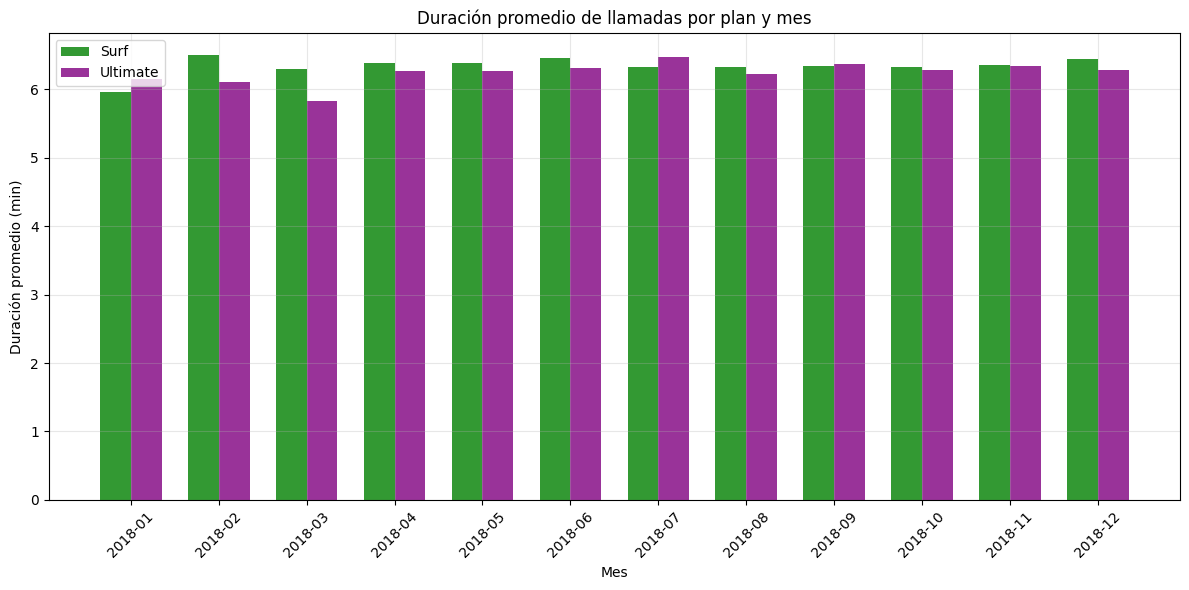

In [ ]:
# Comparar la duración promedio de llamadas por cada plan y por cada mes. Se traza un gráfico de barras para visualización.

# Agregar información del plan a las llamadas 
calls_with_plan = megaline_calls.merge(
    megaline_users[['user_id', 'plan']], 
    on='user_id', 
    how='left'
)
# Crear columna año-mes
calls_with_plan['year_month'] = calls_with_plan['call_date'].dt.to_period('M')

# Calcular duración promedio por plan y mes
avg_duration_by_plan_month = calls_with_plan.groupby(['plan', 'year_month'])['duration'].mean().reset_index()
print("Duración promedio de llamadas por plan y mes:")
print()
print(avg_duration_by_plan_month.head(24))

# Crear gráfico de barras
plt.figure(figsize=(12, 6))

# Separar datos por plan
surf_data = avg_duration_by_plan_month[avg_duration_by_plan_month['plan'] == 'surf']
ultimate_data = avg_duration_by_plan_month[avg_duration_by_plan_month['plan'] == 'ultimate']

# Convertir year_month a string para el eje x
surf_months = surf_data['year_month'].astype(str)
ultimate_months = ultimate_data['year_month'].astype(str)

# Crear posiciones para las barras
x = np.arange(len(surf_months))
width = 0.35

# Crear barras
plt.bar(x - width/2, surf_data['duration'], width, label='Surf', alpha=0.8,color='green')
plt.bar(x + width/2, ultimate_data['duration'], width, label='Ultimate', alpha=0.8, color='purple')

#  Gráfico Personalizado
plt.xlabel('Mes')
plt.ylabel('Duración promedio (min)')
plt.title('Duración promedio de llamadas por plan y mes')
plt.xticks(x, surf_months, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

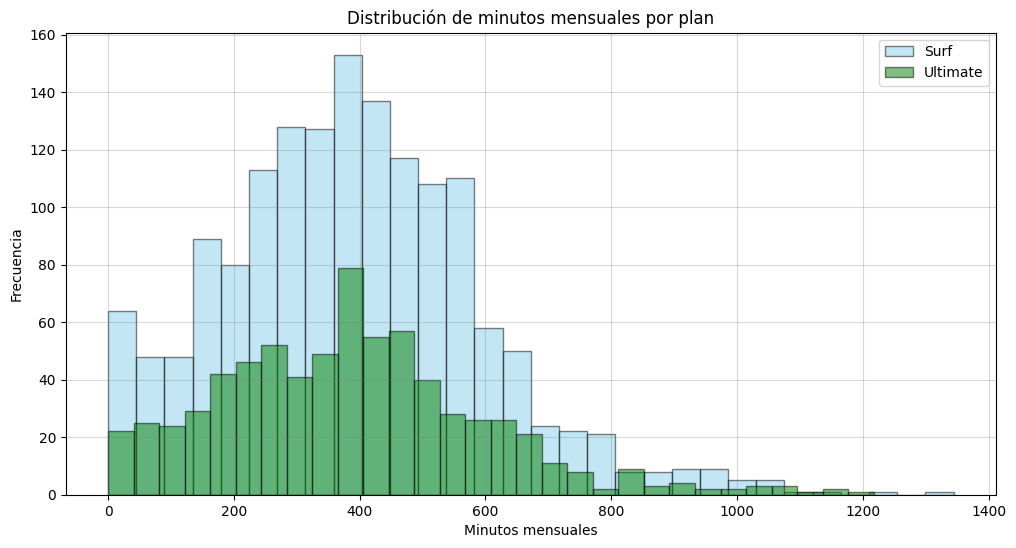

=== ESTADÍSTICAS DE MINUTOS MENSUALES ===
SURF - Media: 387.9 min, Mediana: 382.0 min
ULTIMATE - Media: 386.0 min, Mediana: 376.0 min
Límite Surf: 500 min, Límite Ultimate: 3000 min


In [ ]:
# Comparación de número de minutos mensuales que necesitan los usuarios de cada plan. Se traza un histograma.

# Filtrar datos por plan
surf_minutes = user_monthly_complete[user_monthly_complete['plan'] == 'surf']['total_minutes']
ultimate_minutes = user_monthly_complete[user_monthly_complete['plan'] == 'ultimate']['total_minutes']

# Eliminar valores nulos si los hay
surf_minutes = surf_minutes.dropna()
ultimate_minutes = ultimate_minutes.dropna()

# Crear figura con subplots
plt.figure(figsize=(12, 6))

# Crear histograma superpuesto
plt.hist(surf_minutes, bins=30, alpha=0.5, label='Surf', color='skyblue', edgecolor='black')
plt.hist(ultimate_minutes, bins=30, alpha=0.5, label='Ultimate', color='green', edgecolor='black')

# Personalizar el gráfico
plt.xlabel('Minutos mensuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de minutos mensuales por plan')
plt.legend()
plt.grid(True, alpha=0.3, color='grey')
plt.show()

# Mostrar estadísticas
print("=== ESTADÍSTICAS DE MINUTOS MENSUALES ===")
print(f"SURF - Media: {surf_minutes.mean():.1f} min, Mediana: {surf_minutes.median():.1f} min")
print(f"ULTIMATE - Media: {ultimate_minutes.mean():.1f} min, Mediana: {ultimate_minutes.median():.1f} min")
print(f"Límite Surf: 500 min, Límite Ultimate: 3000 min")

In [ ]:
# Calcular la media y la varianza de la duración mensual de llamadas.
duration_stats = calls_with_plan.groupby('plan')['duration'].agg([
    'mean',    # Media
    'var',     # Varianza
    'std',     # Desviación estándar
    'count'    # Número de llamadas
]).round(2)
print("Estadísticas de duración de llamadas por plan:")
print(duration_stats)

# Separar datos por plan
surf_calls = calls_with_plan[calls_with_plan['plan'] == 'surf']['duration']
ultimate_calls = calls_with_plan[calls_with_plan['plan'] == 'ultimate']['duration']
print("=== PLAN SURF ===")
print(f"Media: {surf_calls.mean():.2f} minutos")
print(f"Varianza: {surf_calls.var():.2f}")
print(f"Desviación estándar: {surf_calls.std():.2f}")
print(f"Número de llamadas: {len(surf_calls)}")
print("\n=== PLAN ULTIMATE ===")
print(f"Media: {ultimate_calls.mean():.2f} minutos")
print(f"Varianza: {ultimate_calls.var():.2f}")
print(f"Desviación estándar: {ultimate_calls.std():.2f}")
print(f"Número de llamadas: {len(ultimate_calls)}")

# Calcular diferencias
mean_diff = ultimate_calls.mean() - surf_calls.mean()
var_diff = ultimate_calls.var() - surf_calls.var()
std_diff = ultimate_calls.std() - surf_calls.std()
print(f"\n=== COMPARACIÓN ===")
print(f"Diferencia en media: {mean_diff:.2f} minutos")
print(f"Diferencia en varianza: {var_diff:.2f}")
print(f"Diferencia en la desviación estandar: {std_diff:.2f}")
print(f"Diferencia en no. de llamadas:{len(surf_calls)-len(ultimate_calls)}")


Estadísticas de duración de llamadas por plan:
          mean    var   std  count
plan                              
surf      6.37  32.92  5.74  94084
ultimate  6.31  32.72  5.72  43651
=== PLAN SURF ===
Media: 6.37 minutos
Varianza: 32.92
Desviación estándar: 5.74
Número de llamadas: 94084

=== PLAN ULTIMATE ===
Media: 6.31 minutos
Varianza: 32.72
Desviación estándar: 5.72
Número de llamadas: 43651

=== COMPARACIÓN ===
Diferencia en media: -0.06 minutos
Diferencia en varianza: -0.20
Diferencia en la desviación estandar: -0.02
Diferencia en no. de llamadas:50433


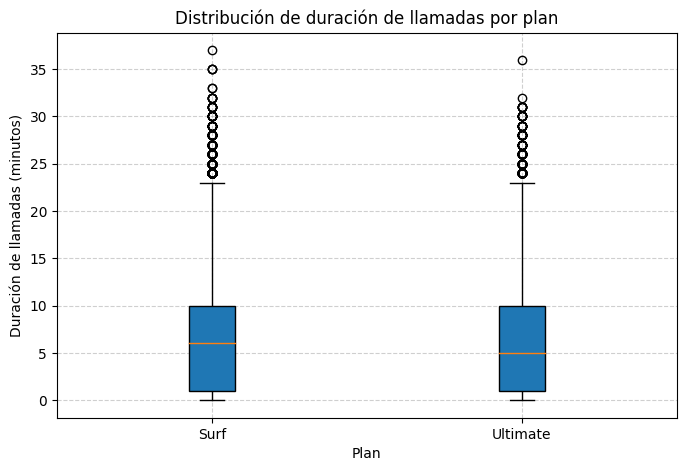

In [ ]:
# Creación de Diagrama de caja para visualizar la distribución de la duración mensual de llamadas
data = [surf_calls, ultimate_calls]
labels = ['Surf', 'Ultimate']
plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=labels, patch_artist=True)
plt.title('Distribución de duración de llamadas por plan')
plt.xlabel('Plan')
plt.ylabel('Duración de llamadas (minutos)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

CONCLUSIONES:

El comportamiento de los usuarios en ambos planes es muy similar, prácticamente idéntico, ya que consumen una cantidad mensual de minutos muy parecida. En el caso del Plan Surf, cuyo límite es de 500 minutos, los usuarios suelen acercarse mucho a ese límite e incluso algunos lo superan, lo que puede generar cargos adicionales. Por el contrario, los usuarios del Plan Ultimate, con un límite de 3000 minutos, están muy lejos de alcanzarlo, lo que indica que se está pagando por una cantidad de minutos adicionales innecesariamente alta. En cuanto a la duración promedio de las llamadas, no se observan diferencias significativas entre ambos planes. Estos resultados indican que la elección del plan por parte de los usuarios probablemente no está determinada por el límite de minutos incluidos.


### Por Mensajes

Total de mensajes por plan y por mes:

        plan year_month  total_messages
0       surf    2018-01              21
1       surf    2018-02             108
2       surf    2018-03             351
3       surf    2018-04             870
4       surf    2018-05            1849
5       surf    2018-06            2454
6       surf    2018-07            3271
7       surf    2018-08            4662
8       surf    2018-09            5968
9       surf    2018-10            8020
10      surf    2018-11            9165
11      surf    2018-12           12275
12  ultimate    2018-01              62
13  ultimate    2018-02             151
14  ultimate    2018-03             243
15  ultimate    2018-04             463
16  ultimate    2018-05             931
17  ultimate    2018-06            1379
18  ultimate    2018-07            1937
19  ultimate    2018-08            2732
20  ultimate    2018-09            3259
21  ultimate    2018-10            4181
22  ultimate    2018-11            4903
2

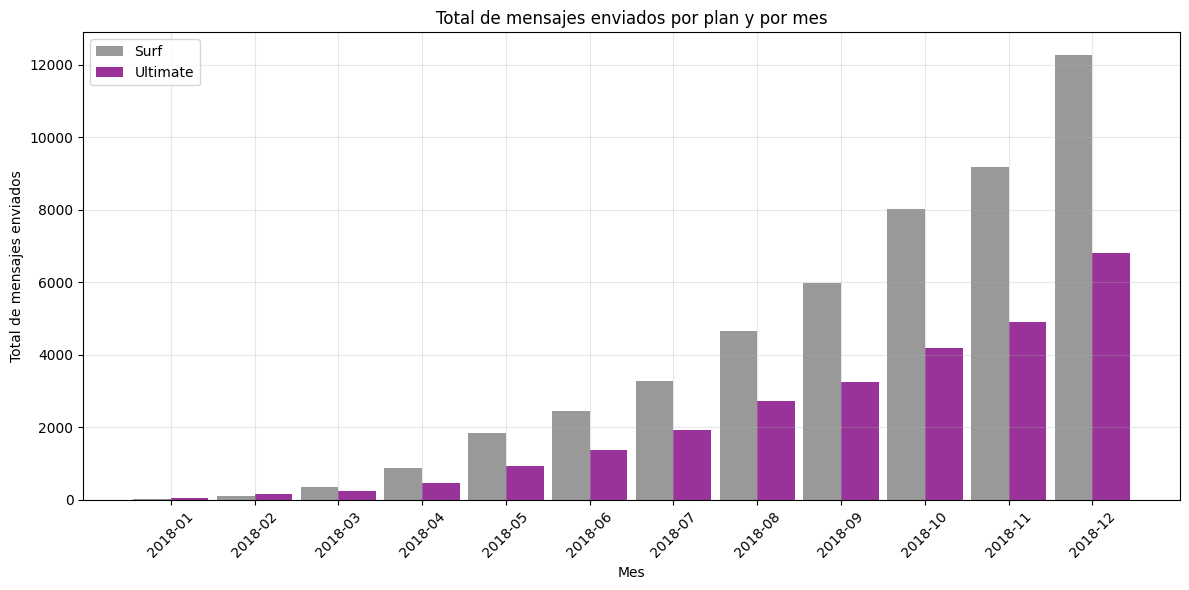

In [ ]:
# Comparar el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

# Agregar información del plan a los mensajes
messages_with_plan = megaline_messages.merge(
    megaline_users[['user_id', 'plan']], 
    on='user_id', 
    how='left'
)
# Crear columna año-mes

messages_with_plan['year_month'] = messages_with_plan['message_date'].dt.to_period('M')

# Calcular el TOTAL de mensajes por plan y mes
total_messages_by_plan_month = (
    messages_with_plan.groupby(['plan', 'year_month'])['id']
    .count()
    .reset_index()
)
total_messages_by_plan_month.rename(columns={'id': 'total_messages'}, inplace=True)
print("Total de mensajes por plan y por mes:")
print()
print(total_messages_by_plan_month.head(24))

# Crear gráfico de barras
plt.figure(figsize=(12, 6))

# Separar datos por plan
surf_data = total_messages_by_plan_month[total_messages_by_plan_month['plan'] == 'surf']
ultimate_data = total_messages_by_plan_month[total_messages_by_plan_month['plan'] == 'ultimate']

# Convertir year_month a string para el eje x
surf_months = surf_data['year_month'].astype(str)
ultimate_months = ultimate_data['year_month'].astype(str)

# Crear posiciones para las barras
x = np.arange(len(surf_months))
width = 0.45

# Crear barras
plt.bar(x - width/2, surf_data['total_messages'], width, label='Surf', alpha=0.8, color='grey')
plt.bar(x + width/2, ultimate_data['total_messages'], width, label='Ultimate', alpha=0.8, color='purple')

# Personalizar gráfico
plt.xlabel('Mes')
plt.ylabel('Total de mensajes enviados')
plt.title('Total de mensajes enviados por plan y por mes')
plt.xticks(x, surf_months, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

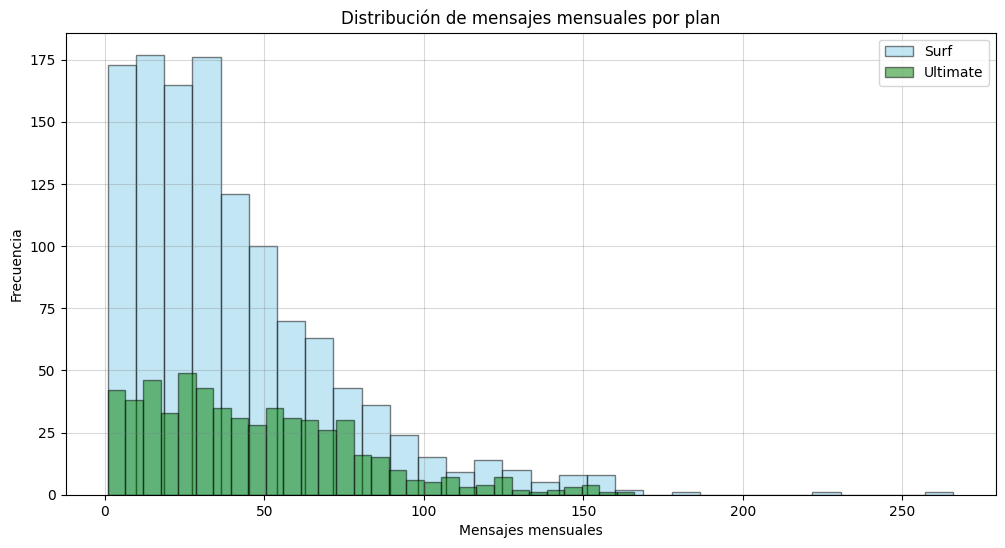

=== ESTADÍSTICAS DE MENSAJES MENSUALES ===
SURF - Media: 40.11 mensajes, Mediana: 32.00 mensajes
ULTIMATE - Media: 46.30 mensajes, Mediana: 41.00 mensajes

=== COMPARACIÓN ===
Diferencia en media: 6.19 mensajes
Diferencia en varianza: -6.16
Diferencia en desviación estándar: -0.09
Diferencia en número de registros: 638

=== TOTAL DE MENSAJES POR PLAN ===
       plan  total_mensajes
0      surf           49014
1  ultimate           27037


In [ ]:
# Comparación del número mensajes de cada plan.Se Traza un histograma.

# Unir mensajes con la información del plan
messages_with_plan = megaline_messages.merge(
    megaline_users[['user_id', 'plan']],
    on='user_id',
    how='left'
)

# Extraer mes y año de cada mensaje
messages_with_plan['month'] = messages_with_plan['message_date'].dt.month
messages_with_plan['year'] = messages_with_plan['message_date'].dt.year

# Contar mensajes por usuario y mes
monthly_messages = messages_with_plan.groupby(['plan', 'user_id', 'year', 'month'])['id'].count().reset_index()
monthly_messages.rename(columns={'id': 'total_messages'}, inplace=True)

# Separar datos por plan
surf_msgs = monthly_messages[monthly_messages['plan'] == 'surf']['total_messages'].dropna()
ultimate_msgs = monthly_messages[monthly_messages['plan'] == 'ultimate']['total_messages'].dropna()

# Crear histograma superpuesto
plt.figure(figsize=(12, 6))
plt.hist(surf_msgs, bins=30, alpha=0.5, label='Surf', color='skyblue', edgecolor='black')
plt.hist(ultimate_msgs, bins=30, alpha=0.5, label='Ultimate', color='green', edgecolor='black')
plt.xlabel('Mensajes mensuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de mensajes mensuales por plan')
plt.legend()
plt.grid(True, alpha=0.3, color='grey')
plt.show()

# Mostrar estadísticas
print("=== ESTADÍSTICAS DE MENSAJES MENSUALES ===")
print(f"SURF - Media: {surf_msgs.mean():.2f} mensajes, Mediana: {surf_msgs.median():.2f} mensajes")
print(f"ULTIMATE - Media: {ultimate_msgs.mean():.2f} mensajes, Mediana: {ultimate_msgs.median():.2f} mensajes")

# Calcular diferencias
mean_diff = ultimate_msgs.mean() - surf_msgs.mean()
var_diff = ultimate_msgs.var() - surf_msgs.var()
std_diff = ultimate_msgs.std() - surf_msgs.std()
print("\n=== COMPARACIÓN ===")
print(f"Diferencia en media: {mean_diff:.2f} mensajes")
print(f"Diferencia en varianza: {var_diff:.2f}")
print(f"Diferencia en desviación estándar: {std_diff:.2f}")
print(f"Diferencia en número de registros: {len(surf_msgs) - len(ultimate_msgs)}")

#Adicional Conteo total de mensajes por plan
total_messages_by_plan = messages_with_plan.groupby('plan')['id'].count().reset_index()
total_messages_by_plan.rename(columns={'id': 'total_mensajes'}, inplace=True)
print("\n=== TOTAL DE MENSAJES POR PLAN ===")
print(total_messages_by_plan)

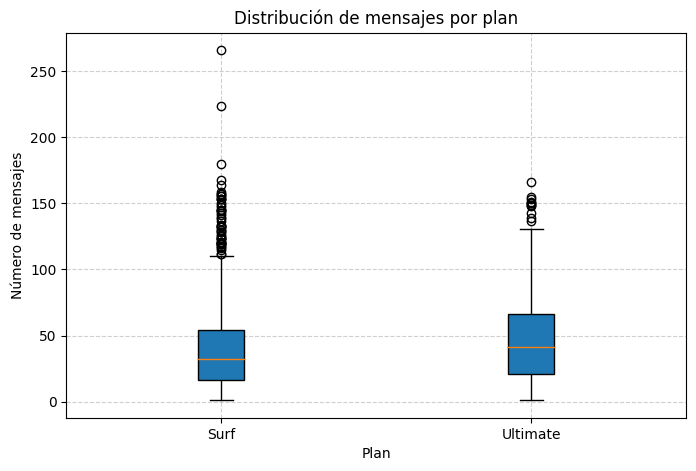

In [ ]:
# Trazar un diagrama de caja para visualizar la distribución de la duración mensual de mensajes x plan

# Diagrama de caja para mensajes
data = [surf_msgs, ultimate_msgs]
labels = ['Surf', 'Ultimate']
plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=labels, patch_artist=True)
plt.title('Distribución de mensajes por plan')
plt.xlabel('Plan')
plt.ylabel('Número de mensajes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

CONCLUSIONES:

Se observa que el Plan Surf genera un mayor número de mensajes en comparación con el Plan Ultimate, lo cual podría deberse a que cuenta con una mayor cantidad de usuarios. Sin embargo, a pesar de que el Plan Ultimate tiene menos usuarios, su promedio mensual de mensajes es superior al del Plan Surf, lo que indica una mayor actividad en el uso de la mensajería. En general, el comportamiento de la mayoría de los usuarios es moderado, con excepción de algunos que envían una cantidad considerablemente alta de mensajes, los cuales se representan en el diagrama de caja mediante los círculos que corresponden a valores atípicos. Además, el gráfico muestra una tendencia creciente, alcanzando su punto máximo en el mes de diciembre. Podríamos conlcuir que los usuarios del plan Ultimate son los que muestran mayor actividad en el servicio de mensajeria que los usuarios del plan Surf.

### Por uso de Internet

Volumen total de internet (MB) por plan y por mes:

        plan year_month    total_MB
0       surf    2018-01     9749.72
1       surf    2018-02   109609.59
2       surf    2018-03   306945.12
3       surf    2018-04   599210.15
4       surf    2018-05  1073099.33
5       surf    2018-06  1484248.33
6       surf    2018-07  2030815.67
7       surf    2018-08  2720843.68
8       surf    2018-09  3218737.67
9       surf    2018-10  4102786.41
10      surf    2018-11  4624009.00
11      surf    2018-12  5766125.26
12  ultimate    2018-01    27672.37
13  ultimate    2018-02   119901.66
14  ultimate    2018-03   219858.22
15  ultimate    2018-04   338554.75
16  ultimate    2018-05   482109.99
17  ultimate    2018-06   720882.29
18  ultimate    2018-07   964339.92
19  ultimate    2018-08  1264845.13
20  ultimate    2018-09  1459408.78
21  ultimate    2018-10  1866930.66
22  ultimate    2018-11  2163278.04
23  ultimate    2018-12  2766801.97


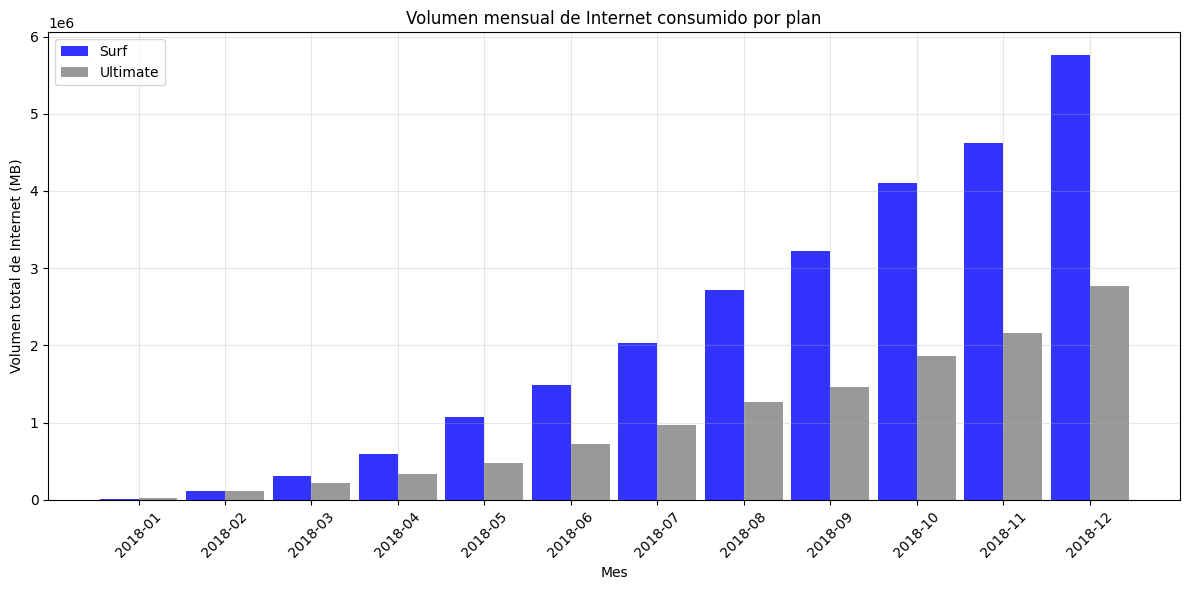

In [ ]:
# Comparar la cantidad de tráfico de Internet consumido por usuarios por plan

# Unir el uso de internet con la información del plan
internet_with_plan = megaline_internet.merge(
    megaline_users[['user_id', 'plan']], 
    on='user_id', 
    how='left'
)
# Crear columna año-mes
internet_with_plan['year_month'] = internet_with_plan['session_date'].dt.to_period('M')

# Calcular el TOTAL de MB consumidos por plan y mes
total_internet_by_plan_month = (
    internet_with_plan.groupby(['plan', 'year_month'])['mb_used']
    .sum()
    .reset_index()
)
total_internet_by_plan_month.rename(columns={'mb_used': 'total_MB'}, inplace=True)
print("Volumen total de internet (MB) por plan y por mes:\n")
print(total_internet_by_plan_month.head(24))

# --- Gráfico de barras comparativo ---
plt.figure(figsize=(12, 6))

# Separar datos por plan
surf_data = total_internet_by_plan_month[total_internet_by_plan_month['plan'] == 'surf']
ultimate_data = total_internet_by_plan_month[total_internet_by_plan_month['plan'] == 'ultimate']

# Convertir year_month a string para el eje x
surf_months = surf_data['year_month'].astype(str)
ultimate_months = ultimate_data['year_month'].astype(str)

# Crear posiciones para las barras
x = np.arange(len(surf_months))
width = 0.45

# Crear barras
plt.bar(x - width/2, surf_data['total_MB'], width, label='Surf', alpha=0.8, color='blue')
plt.bar(x + width/2, ultimate_data['total_MB'], width, label='Ultimate', alpha=0.8, color='grey')

# Personalizar gráfico
plt.xlabel('Mes')
plt.ylabel('Volumen total de Internet (MB)')
plt.title('Volumen mensual de Internet consumido por plan')
plt.xticks(x, surf_months, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


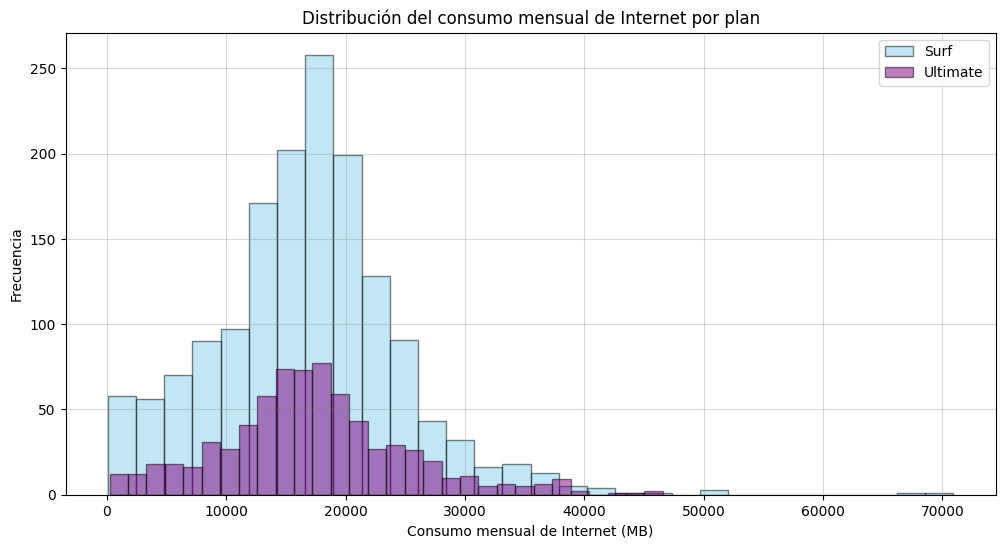

=== ESTADÍSTICAS DE CONSUMO MENSUAL DE INTERNET (MB) ===
SURF - Media: 16717.70 MB, Mediana: 16923.83 MB
ULTIMATE - Media: 17238.64 MB, Mediana: 16863.45 MB

=== COMPARACIÓN ENTRE PLANES ===
Diferencia en media: 520.94 MB
Diferencia en varianza: -843377.77
Diferencia en desviación estándar: -53.66
Diferencia en número de registros: 839

=== TOTAL DE INTERNET CONSUMIDO POR PLAN (MB) ===
       plan  total_MB_consumido
0      surf         26046179.93
1  ultimate         12394583.78


In [ ]:
#Compara volumen total mensual de internet por Plan
# Unir el uso de internet con la información del plan
internet_with_plan = megaline_internet.merge(
    megaline_users[['user_id', 'plan']],
    on='user_id',
    how='left'
)
# Extraer mes y año de cada sesión
internet_with_plan['month'] = internet_with_plan['session_date'].dt.month
internet_with_plan['year'] = internet_with_plan['session_date'].dt.year
# Calcular volumen total de MB por usuario, plan y mes
monthly_internet = (
    internet_with_plan.groupby(['plan', 'user_id', 'year', 'month'])['mb_used']
    .sum()
    .reset_index()
)
monthly_internet.rename(columns={'mb_used': 'total_MB'}, inplace=True)
# Separar datos por plan
surf_data = monthly_internet[monthly_internet['plan'] == 'surf']['total_MB'].dropna()
ultimate_data = monthly_internet[monthly_internet['plan'] == 'ultimate']['total_MB'].dropna()
# --- Histograma superpuesto ---
plt.figure(figsize=(12, 6))
plt.hist(surf_data, bins=30, alpha=0.5, label='Surf', color='skyblue', edgecolor='black')
plt.hist(ultimate_data, bins=30, alpha=0.5, label='Ultimate', color='purple', edgecolor='black')
plt.xlabel('Consumo mensual de Internet (MB)')
plt.ylabel('Frecuencia')
plt.title('Distribución del consumo mensual de Internet por plan')
plt.legend()
plt.grid(True, alpha=0.3, color='grey')
plt.show()
# --- Estadísticas descriptivas ---
print("=== ESTADÍSTICAS DE CONSUMO MENSUAL DE INTERNET (MB) ===")
print(f"SURF - Media: {surf_data.mean():.2f} MB, Mediana: {surf_data.median():.2f} MB")
print(f"ULTIMATE - Media: {ultimate_data.mean():.2f} MB, Mediana: {ultimate_data.median():.2f} MB")
# --- Comparación entre planes ---
mean_diff = ultimate_data.mean() - surf_data.mean()
var_diff = ultimate_data.var() - surf_data.var()
std_diff = ultimate_data.std() - surf_data.std()
print("\n=== COMPARACIÓN ENTRE PLANES ===")
print(f"Diferencia en media: {mean_diff:.2f} MB")
print(f"Diferencia en varianza: {var_diff:.2f}")
print(f"Diferencia en desviación estándar: {std_diff:.2f}")
print(f"Diferencia en número de registros: {len(surf_data) - len(ultimate_data)}")
# --- Conteo total de sesiones por plan ---
total_internet_by_plan = internet_with_plan.groupby('plan')['mb_used'].sum().reset_index()
total_internet_by_plan.rename(columns={'mb_used': 'total_MB_consumido'}, inplace=True)
print("\n=== TOTAL DE INTERNET CONSUMIDO POR PLAN (MB) ===")
print(total_internet_by_plan)

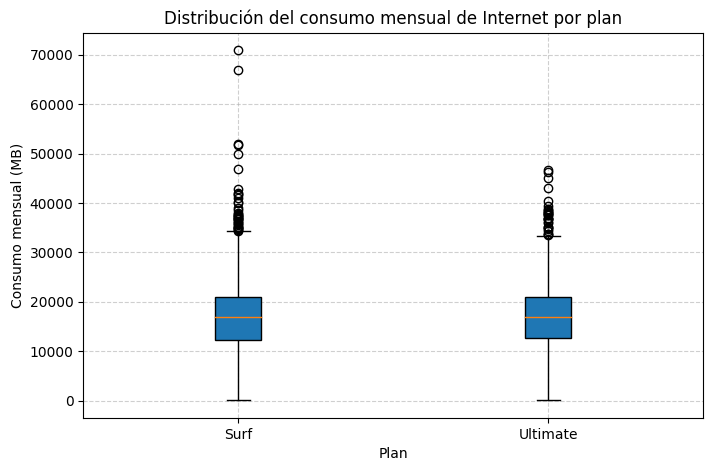

In [ ]:
# --- Diagrama de caja (Boxplot) ---
data = [surf_data, ultimate_data]  # Estas SÍ existen
labels = ['Surf', 'Ultimate']
plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=labels, patch_artist=True)
plt.title('Distribución del consumo mensual de Internet por plan')
plt.xlabel('Plan')
plt.ylabel('Consumo mensual (MB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

CONCLUSIONES:

De manera similar al comportamiento observado en las llamadas, el uso de internet por parte de los usuarios presenta patrones parecidos entre ambos planes. El Plan Surf, al contar con una mayor cantidad de usuarios, genera un volumen total de consumo más alto; sin embargo, el comportamiento individual de sus usuarios es comparable al de los usuarios del Plan Ultimate. La principal diferencia radica en el número de suscriptores registrados.

No obstante, los datos muestran que los usuarios del Plan Ultimate presentan un consumo más estable, mientras que los del Plan Surf exhiben una mayor dispersión y variabilidad. Asimismo, se identifican varios puntos atípicos, lo que indica que en ambos planes existe un grupo considerable de usuarios que consume una cantidad de datos significativamente superior a la media. En general, el comportamiento de los usuarios de ambos planes refleja una tendencia creciente a lo largo del año 2018.

## Ingresos mensuales totales por plan

Ingresos totales mensuales por plan:

        plan year_month  total_revenue
0       surf    2018-01          40.00
1       surf    2018-02         306.93
2       surf    2018-03        1050.50
3       surf    2018-04        2012.46
4       surf    2018-05        3612.35
5       surf    2018-06        4717.13
6       surf    2018-07        7483.12
7       surf    2018-08       10248.94
8       surf    2018-09       11186.50
9       surf    2018-10       15337.19
10      surf    2018-11       16214.87
11      surf    2018-12       22160.72
12  ultimate    2018-01         280.00
13  ultimate    2018-02         490.00
14  ultimate    2018-03         896.00
15  ultimate    2018-04        1533.00
16  ultimate    2018-05        2051.00
17  ultimate    2018-06        3367.00
18  ultimate    2018-07        4242.00
19  ultimate    2018-08        5173.00
20  ultimate    2018-09        6195.00
21  ultimate    2018-10        7665.00
22  ultimate    2018-11        9107.00
23  ultimate    2018-12   

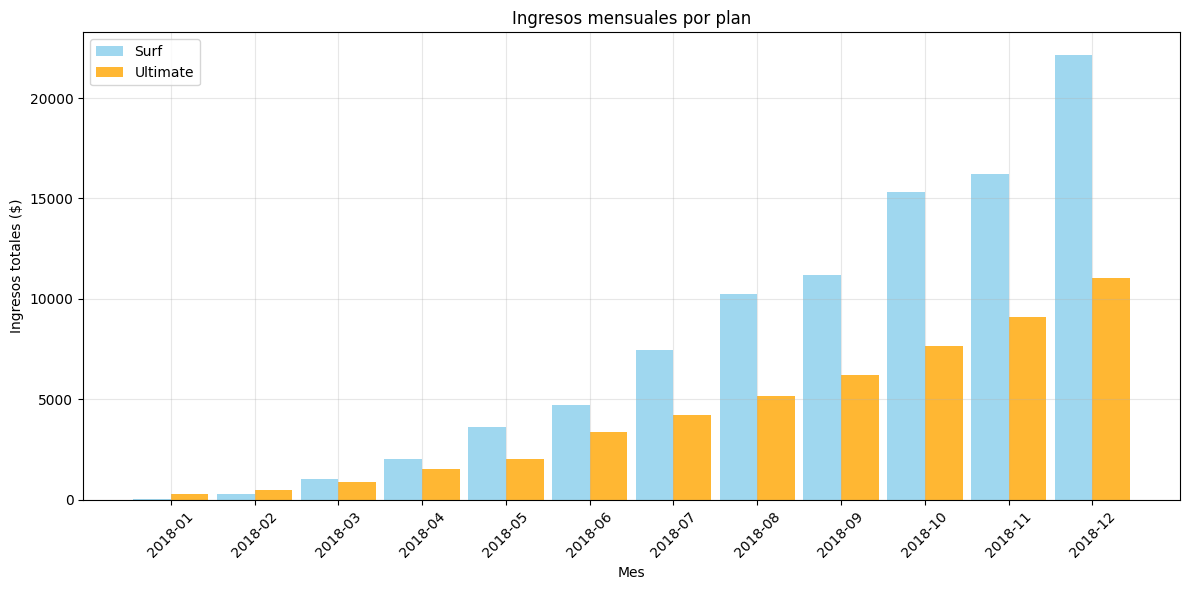

In [ ]:
# --- Calcular los ingresos mensuales totales por plan ---
total_revenue_by_plan_month = (
    user_monthly_complete.groupby(['plan', 'year_month'])['total_revenue']
    .sum()
    .reset_index()
)
print("Ingresos totales mensuales por plan:\n")
print(total_revenue_by_plan_month.head(24))

# --- Gráfico de barras comparativo ---
plt.figure(figsize=(12, 6))

# Separar datos por plan
surf_data = total_revenue_by_plan_month[total_revenue_by_plan_month['plan'] == 'surf']
ultimate_data = total_revenue_by_plan_month[total_revenue_by_plan_month['plan'] == 'ultimate']

# Eje x (meses)
surf_months = surf_data['year_month']
ultimate_months = ultimate_data['year_month']

# Crear posiciones para las barras
x = np.arange(len(surf_months))
width = 0.45

# Crear barras
plt.bar(x - width/2, surf_data['total_revenue'], width, label='Surf', alpha=0.8, color='skyblue')
plt.bar(x + width/2, ultimate_data['total_revenue'], width, label='Ultimate', alpha=0.8, color='orange')

# Personalizar gráfico
plt.xlabel('Mes')
plt.ylabel('Ingresos totales ($)')
plt.title('Ingresos mensuales por plan')
plt.xticks(x, surf_months, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

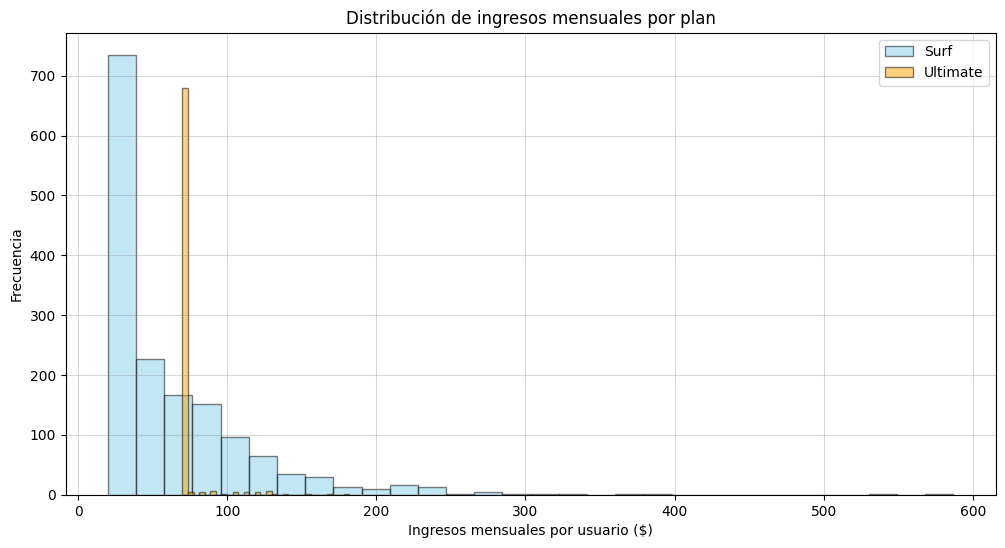

=== ESTADÍSTICAS DE INGRESOS MENSUALES ===
SURF - Media: $59.99, Mediana: $40.00
ULTIMATE - Media: $72.31, Mediana: $70.00

=== COMPARACIÓN ENTRE PLANES ===
Diferencia en media: $12.32
Diferencia en varianza: -2911.11
Diferencia en desviación estándar: -43.75
Diferencia en número de registros: 853

=== TOTAL DE INGRESOS POR PLAN ===
       plan  total_revenue_total
0      surf             94370.71
1  ultimate             52066.00


In [ ]:
# --- Comparar ingresos mensuales totales por plan ---
revenue_with_plan = user_monthly_complete.copy()

# Extraer mes y año de la columna de fecha (si no existe, usa year_month directamente)
revenue_with_plan['month'] = revenue_with_plan['year_month'].dt.month
revenue_with_plan['year'] = revenue_with_plan['year_month'].dt.year

# Calcular ingresos totales por usuario, plan y mes
monthly_revenue = (
    revenue_with_plan.groupby(['plan', 'user_id', 'year', 'month'])['total_revenue']
    .sum()
    .reset_index()
)
monthly_revenue.rename(columns={'total_revenue': 'total_revenue_month'}, inplace=True)

# --- Separar datos por plan ---
surf_data = monthly_revenue[monthly_revenue['plan'] == 'surf']['total_revenue_month'].dropna()
ultimate_data = monthly_revenue[monthly_revenue['plan'] == 'ultimate']['total_revenue_month'].dropna()

# --- Histograma superpuesto ---
plt.figure(figsize=(12, 6))
plt.hist(surf_data, bins=30, alpha=0.5, label='Surf', color='skyblue', edgecolor='black')
plt.hist(ultimate_data, bins=30, alpha=0.5, label='Ultimate', color='orange', edgecolor='black')
plt.xlabel('Ingresos mensuales por usuario ($)')
plt.ylabel('Frecuencia')
plt.title('Distribución de ingresos mensuales por plan')
plt.legend()
plt.grid(True, alpha=0.3, color='grey')
plt.show()

# --- Estadísticas descriptivas ---
print("=== ESTADÍSTICAS DE INGRESOS MENSUALES ===")
print(f"SURF - Media: ${surf_data.mean():.2f}, Mediana: ${surf_data.median():.2f}")
print(f"ULTIMATE - Media: ${ultimate_data.mean():.2f}, Mediana: ${ultimate_data.median():.2f}")

# --- Comparación entre planes ---
mean_diff = ultimate_data.mean() - surf_data.mean()
var_diff = ultimate_data.var() - surf_data.var()
std_diff = ultimate_data.std() - surf_data.std()
print("\n=== COMPARACIÓN ENTRE PLANES ===")
print(f"Diferencia en media: ${mean_diff:.2f}")
print(f"Diferencia en varianza: {var_diff:.2f}")
print(f"Diferencia en desviación estándar: {std_diff:.2f}")
print(f"Diferencia en número de registros: {len(surf_data) - len(ultimate_data)}")

# --- Total de ingresos por plan ---
total_revenue_by_plan = revenue_with_plan.groupby('plan')['total_revenue'].sum().reset_index()
total_revenue_by_plan.rename(columns={'total_revenue': 'total_revenue_total'}, inplace=True)
print("\n=== TOTAL DE INGRESOS POR PLAN ===")
print(total_revenue_by_plan)


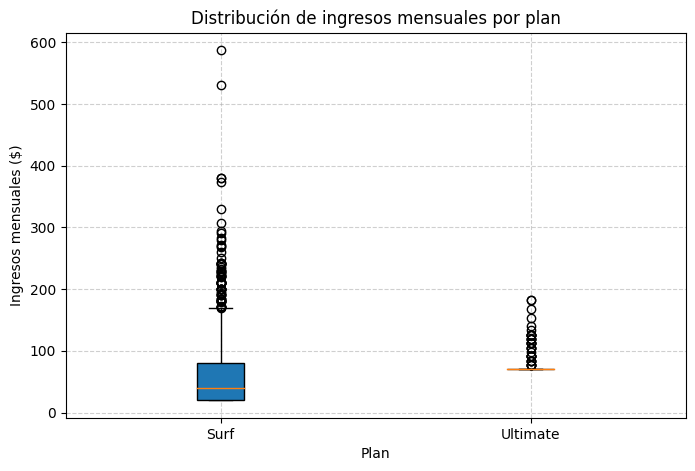

In [ ]:
# Diagrama de caja (Boxplot) de ingresos mensuales por plan 
data = [surf_data, ultimate_data]  # Ingresos mensuales por usuario
labels = ['Surf', 'Ultimate']
plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=labels, patch_artist=True)
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Plan')
plt.ylabel('Ingresos mensuales ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


CONCLUSIONES:

El plan Surf muestra ingresos muy variables; la mayoría de los usuarios de este plan generan montos bajos, aunque algunos alcanzan cifras más altas. Los usuarios del plan Ultimate tienen ingresos más concentrados y predecibles. A pesar de esto, el plan Surf, por contar con un mayor número de usuarios, genera aproximadamente tres veces más ingresos totales que el plan Ultimate. Podemos concluir que el plan Surf resulta más rentable, mientras que el plan Ultimate podría modificarse y optimizarse para incrementar ingresos y uso. Ambos planes mostraron un crecimiento durante 2018.


## Prueba de las hipótesis estadísticas

In [ ]:
# Prueba las hipótesis 
print(f"Prueba de hipótesis 2")
print()
##Hipótesis Nula##

print(f"Hipótesis Nula: ")
print(f"Los ingresos promedio de ambos planes son iguales")

##Hipótesis Alternativa##

print(f"Hipótesis Alternativa: ")
print(f"Los ingresos promedio de ambos planes son diferentes")

##Nivel de significancia##

alpha = 0.05  # 5% de nivel de significancia

# Prueba las hipótesis
# Obtener ingresos mensuales por plan
surf_revenues = user_monthly_complete[user_monthly_complete['plan'] == 'surf']['total_revenue']
ultimate_revenues = user_monthly_complete[user_monthly_complete['plan'] == 'ultimate']['total_revenue']

# Verificar los datos
print()
print(f"Ingresos Surf - Cantidad: {len(surf_revenues)}, Promedio: ${surf_revenues.mean():.2f}")
print(f"Ingresos Ultimate - Cantidad: {len(ultimate_revenues)}, Promedio: ${ultimate_revenues.mean():.2f}")

from scipy import stats

# Realizar la prueba t de dos muestras
t_stat, p_value = stats.ttest_ind(ultimate_revenues, surf_revenues)

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significancia: {alpha}")

if p_value < alpha:
    print(f"\nResultado: p-value ({p_value:.6f}) < α ({alpha})")
    print("RECHAZAMOS la hipótesis nula")
    print("Conclusión: Existe diferencia significativa entre los ingresos promedio")
else:
    print(f"\nResultado: p-value ({p_value:.6f}) >= α ({alpha})")
    print("NO RECHAZAMOS la hipótesis nula")
    print("Conclusión: No hay evidencia de diferencia significativa")




Prueba de hipótesis 2

Hipótesis Nula: 
Los ingresos promedio de ambos planes son iguales
Hipótesis Alternativa: 
Los ingresos promedio de ambos planes son diferentes

Ingresos Surf - Cantidad: 1573, Promedio: $59.99
Ingresos Ultimate - Cantidad: 720, Promedio: $72.31
Estadístico t: 5.9363
Valor p: 0.000000
Nivel de significancia: 0.05

Resultado: p-value (0.000000) < α (0.05)
RECHAZAMOS la hipótesis nula
Conclusión: Existe diferencia significativa entre los ingresos promedio


In [ ]:
# Prueba las hipótesis
print(f"Prueba de hipótesis 2")
print()

##Hipótesis Nula##
print(f"Hipótesis Nula: ")
print(f"El ingreso promedio de los usuarios de NY-NJ es igual al ingreso promedio de usuarios de otras regiones")

##Hipótesis Alternativa##
print(f"Hipótesis Alternativa: ")
print(f"El ingreso promedio de los usuarios de NY-NJ es diferente al ingreso promedio de usuarios de otras regiones")

# Crear columna de región basada en las ciudades (Identificar usuarios de NY-NJ)
megaline_users['region'] = megaline_users['city'].apply(
    lambda x: 'NY/NJ' if isinstance(x, str) and 
    ('new york' in x.lower() or 'new jersey' in x.lower()) 
    else 'Otras regiones'
)
# Verificar cuántos usuarios hay por región
print(megaline_users['region'].value_counts())

# Usar user_monthly_complete que tiene 'total_revenue'
revenue_with_region = user_monthly_complete.merge(
    megaline_users[['user_id', 'region']],
    on='user_id',
    how='left'
)
# Separar ingresos por región
ny_nj_revenues = revenue_with_region[
    revenue_with_region['region'] == 'NY/NJ'
]['total_revenue']
other_revenues = revenue_with_region[
    revenue_with_region['region'] == 'Otras regiones'
]['total_revenue']

# Verificar los datos
print(f"Ingresos NY/NJ - Cantidad: {len(ny_nj_revenues)}, Promedio: ${ny_nj_revenues.mean():.2f}")
print(f"Ingresos Otras regiones - Cantidad: {len(other_revenues)}, Promedio: ${other_revenues.mean():.2f}")

# Establecer nivel de significancia
alpha = 0.05

# Realizar la prueba t
t_stat, p_value = stats.ttest_ind(ny_nj_revenues, other_revenues)
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significancia: {alpha}")
if p_value < alpha:
    print(f"\nResultado: p-value ({p_value:.6f}) < α ({alpha})")
    print(f"RECHAZAMOS la hipótesis nula")
    print("Conclusión: Existe diferencia significativa entre los ingresos promedio de los usuarios de NY-NJ es igual al ingreso promedio de usuarios de otras regiones.")

Prueba de hipótesis 2

Hipótesis Nula: 
El ingreso promedio de los usuarios de NY-NJ es igual al ingreso promedio de usuarios de otras regiones
Hipótesis Alternativa: 
El ingreso promedio de los usuarios de NY-NJ es diferente al ingreso promedio de usuarios de otras regiones
Otras regiones    420
NY/NJ              80
Name: region, dtype: int64
Ingresos NY/NJ - Cantidad: 377, Promedio: $59.34
Ingresos Otras regiones - Cantidad: 1916, Promedio: $64.75
Estadístico t: -2.0699
Valor p: 0.038577
Nivel de significancia: 0.05

Resultado: p-value (0.038577) < α (0.05)
RECHAZAMOS la hipótesis nula
Conclusión: Existe diferencia significativa entre los ingresos promedio de los usuarios de NY-NJ es igual al ingreso promedio de usuarios de otras regiones.


## Conclusión general
A través de este estudio de análisis estadístico se evaluó el comportamiento de 500 usuarios de Megaline, una compañía de telecomunicaciones. Se observó que los usuarios manejan dos tarifas, y que el comportamiento en ambos planes, Surf y Ultimate, es muy similar en cuanto al uso de minutos, mensajes e internet. Sin embargo, las diferencias principales se deben al número de suscriptores y a la estabilidad del consumo. El Plan Surf, al contar con más usuarios, genera un mayor volumen total de llamadas, mensajes e internet, así como ingresos totales superiores, aunque con mayor variabilidad y dispersión. Por su parte, el Plan Ultimate presenta un uso más estable, mayor actividad promedio por usuario en mensajería y datos más predecibles, aunque sus ingresos totales son menores debido a su menor base de usuarios. Esto indica que la elección del plan no está determinada únicamente por los límites incluidos y sugiere que el Plan Surf es más rentable a nivel global, mientras que el Plan Ultimate podría optimizarse para incrementar su eficiencia y fomentar un mayor uso.